# Imports

In [1]:
## load packages 
import pandas as pd
import re
import numpy as np
import pickle
import matplotlib.pyplot as plt
import seaborn as sns

## nltk imports
from nltk.tokenize import word_tokenize, wordpunct_tokenize
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer

## sklearn imports
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

## print mult things
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

## random
import random

In [3]:
#pull cleaned data
df2020 = pd.read_csv('../data/2020cleaned.csv')
df2010 = pd.read_csv('../data/2010cleaned.csv')

In [4]:
#coding new tract_num variable to standardize the index and census_tract variables in each dataset in order to permit merging
df2010['tract_num'] = df2010['index'].str.extract(r'(\d+\.?\d*)')[0]
df2020['tract_num'] = df2020['census_tract'].str.extract(r'(\d+\.?\d*)')[0]

In [5]:
#merging datasets on tract_num
dfmerged = df2010.merge(
    df2020,
    left_on='tract_num',
    right_on='tract_num',
    suffixes=('_2010', '_2020')
)

In [6]:
#creating new four-way train_access columns based on near_path and near_hblr boolean columns
def categorize(row):
    if row['near_hblr_2020'] and not row['near_path_2020']:
        return 'hblr_only'
    elif row['near_path_2020'] and not row['near_hblr_2020']:
        return 'path_only'
    elif row['near_hblr_2020'] and row['near_path_2020']:
        return 'near_both'
    else:
        return 'near_neither'

dfmerged['train_access'] = dfmerged.apply(categorize, axis=1)

In [7]:
dfmerged.head()

,index,Total:,Hispanic or Latino_2010,White alone_2010,Black or African American alone_2010,American Indian and Alaska Native alone_2010,Asian alone_2010,Native Hawaiian and Other Pacific Islander alone_2010,Some Other Race alone_2010,Two or More Races:,...,Renter-occupied housing units,near_hblr_2020,white_pct_2020,black_pct_2020,asian_pct_2020,amerindian_pct,other_pct_2020,hispanic_pct_2020,near_path_2020,train_access
0,"Census Tract 2, Hudson County, New Jersey",5409.0,3362.0,987.0,310.0,12,630.0,0,31.0,77,...,75.00%,False,15.9,5.9,19.3,0.2,1.6,54.8,False,near_neither
1,"Census Tract 3, Hudson County, New Jersey",4220.0,2346.0,1267.0,177.0,10,312.0,0,35.0,73,...,68.70%,True,31.6,3.6,12.6,0.1,1.1,48.4,False,hblr_only
2,"Census Tract 4, Hudson County, New Jersey",3991.0,1297.0,1013.0,205.0,10,1297.0,0,39.0,130,...,68.10%,False,16.8,3.7,41.6,0.5,1.2,34.5,False,near_neither
3,"Census Tract 5, Hudson County, New Jersey",4311.0,1928.0,977.0,224.0,10,1062.0,0,48.0,62,...,69.40%,False,22.2,4.6,30.3,0.2,1.3,38.8,False,near_neither
4,"Census Tract 6, Hudson County, New Jersey",5750.0,2494.0,1373.0,366.0,11,1303.0,1,38.0,164,...,76.00%,False,21.4,4.9,27.7,0.2,1.3,42.3,False,near_neither


In [8]:
#creating percent change columns from 2010 to 2020
race_cols = ['white_pct', 'black_pct', 'asian_pct', 'hispanic_pct', 'other_pct']

for col in race_cols:
    dfmerged[f'{col}_change'] = dfmerged[f'{col}_2020'] - dfmerged[f'{col}_2010']

change_cols = ['census_tract'] + [f'{col}_change' for col in race_cols]

In [9]:
dfmerged.groupby(['near_hblr_2020', 'near_path_2020'])[['white_pct_change', 'black_pct_change', 'asian_pct_change', 'hispanic_pct_change', 'other_pct_change']].mean().reset_index()

,near_hblr_2020,near_path_2020,white_pct_change,black_pct_change,asian_pct_change,hispanic_pct_change,other_pct_change
0,False,False,-4.036624,-0.824935,2.435961,0.369273,0.724758
1,False,True,0.200307,-1.100665,3.602664,-3.847357,0.316643
2,True,False,-2.369681,-3.603145,2.334345,1.935732,0.475623
3,True,True,-3.854618,-0.735017,2.552192,0.209710,0.555066


In [10]:
change_cols = ['white_pct_change', 'black_pct_change', 'asian_pct_change',
               'hispanic_pct_change', 'other_pct_change']

mergedgrouped = dfmerged.groupby('train_access')[change_cols].mean().reset_index()
mergedgrouped

,train_access,white_pct_change,black_pct_change,asian_pct_change,hispanic_pct_change,other_pct_change
0,hblr_only,-2.369681,-3.603145,2.334345,1.935732,0.475623
1,near_both,-3.854618,-0.735017,2.552192,0.209710,0.555066
2,near_neither,-4.036624,-0.824935,2.435961,0.369273,0.724758
3,path_only,0.200307,-1.100665,3.602664,-3.847357,0.316643


<Figure size 1200x600 with 0 Axes>

<Axes: xlabel='train_access', ylabel='pct_change'>

Text(0.5, 1.0, 'Percentage Point Change in Racial Demographics (2010–2020)')

Text(0.5, 0, 'Proximity to Public Transit')

Text(0, 0.5, 'Percentage Point Change')

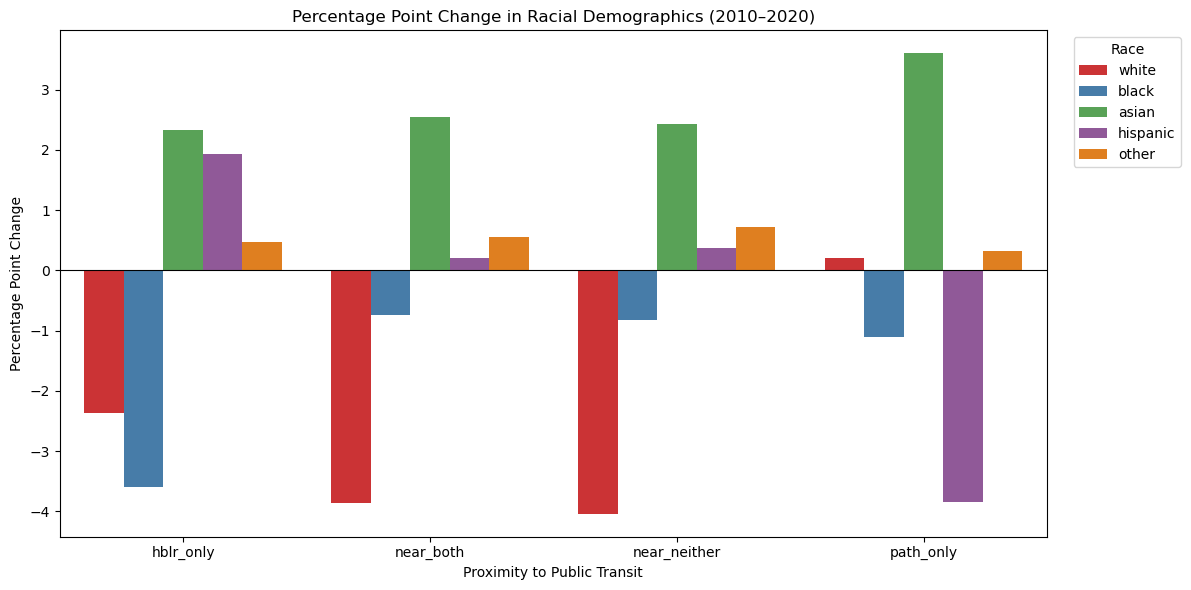

In [11]:
#creating plot
long_df = mergedgrouped.melt(
    id_vars='train_access',
    value_vars=change_cols,
    var_name='race',
    value_name='pct_change'
)

# Clean up race labels (remove '_pct_change' suffix)
long_df['race'] = long_df['race'].str.replace('_pct_change', '', regex=False)

# Set up the plot
plt.figure(figsize=(12, 6))
sns.barplot(
    data=long_df,
    x='train_access',
    y='pct_change',
    hue='race',
    palette='Set1'
)

# Add a horizontal line at y=0 so negative bars are clearly visible
plt.axhline(0, color='black', linewidth=0.8)

# Labels and title
plt.title('Percentage Point Change in Racial Demographics (2010–2020)')
plt.xlabel('Proximity to Public Transit')
plt.ylabel('Percentage Point Change')
plt.legend(title='Race', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()

plt.savefig("hudsonrace1.png", bbox_inches="tight")
plt.show()